# PySpark Assignment - Data Engineering Task Part 2

This notebook implements all required tasks using PySpark DataFrame API, including:
- Loading CSV files
- Data exploration
- Transformations (year, month, day, 2024 filter)
- Aggregations
- Joins
- Advanced analysis + charts
- Writing Parquet and CSV outputs
- Reloading from Parquet

In [29]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
import os
import glob
import shutil

spark = (
    SparkSession.builder
    .appName('assignment-part2')
    .master('local[*]')
    .getOrCreate()
)

spark

## 1. Load the Data
Load orders.csv and customers.csv into PySpark DataFrames.

In [30]:
customers_raw = spark.read.option('header', True).csv('data/customers.csv')
orders_raw = spark.read.option('header', True).csv('data/orders.csv')

print('Raw files loaded.')

Raw files loaded.


### Step 1.1 - EDA

In [31]:

datasets = {
    "CUSTOMERS": customers_raw,
    "ORDERS": orders_raw
}


In [32]:
for name, df in datasets.items():

    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")

    print(f"Rows: {df.count()}")
    print(f"Columns: {len(df.columns)}")

    print("\nSchema")
    df.printSchema()

    print("\nSample Data")
    df.limit(10).show(truncate=False)

    print("\nNull Values")
    df.select([
        count(
            when(
                col(c).isNull() | (trim(col(c)) == ""),
                c
            )
        ).alias(c)
        for c in df.columns
    ]).show()

    print("\nDistinct Values")
    df.select([
        count_distinct(c).alias(c)
        for c in df.columns
    ]).show()



CUSTOMERS
Rows: 501
Columns: 3

Schema
root
 |-- customer_id: string (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- customer_city: string (nullable = true)


Sample Data
+-----------+-----------------+------------------+
|customer_id|customer_name    |customer_city     |
+-----------+-----------------+------------------+
|1          |Edgar Love       |Glennshire        |
|2          |Nancy Nelson     |Daystad           |
|3          |Dalton Russell   |Edwardsmouth      |
|4          |Christian Solomon|South Emilyborough|
|5          |Brandon Ward     |Evansview         |
|6          |Terry Watkins    |Pamelamouth       |
|7          |Kathleen Smith   |Carriemouth       |
|8          |Troy Collins     |Bernardshire      |
|9          |Michael Williams |Tylerfort         |
|10         |Megan Gordon     |Lake Paulbury     |
+-----------+-----------------+------------------+


Null Values
+-----------+-------------+-------------+
|customer_id|customer_name|customer_ci

In [33]:
for name, df in datasets.items():

    print(f"\n{name}")

    for c in df.columns:

        print(f"\n--- {c} ---")

        df.select(
            count("*").alias("rows"),
            count_distinct(c).alias("distinct_values"),
            count(
                when(
                    col(c).isNull() | (trim(col(c)) == ""),
                    c
                )
            ).alias("missing_values")
        ).show()



CUSTOMERS

--- customer_id ---
+----+---------------+--------------+
|rows|distinct_values|missing_values|
+----+---------------+--------------+
| 501|            500|             1|
+----+---------------+--------------+


--- customer_name ---
+----+---------------+--------------+
|rows|distinct_values|missing_values|
+----+---------------+--------------+
| 501|            498|             3|
+----+---------------+--------------+


--- customer_city ---
+----+---------------+--------------+
|rows|distinct_values|missing_values|
+----+---------------+--------------+
| 501|            490|             3|
+----+---------------+--------------+


ORDERS

--- order_id ---
+-----+---------------+--------------+
| rows|distinct_values|missing_values|
+-----+---------------+--------------+
|10003|          10000|             3|
+-----+---------------+--------------+


--- customer_id ---
+-----+---------------+--------------+
| rows|distinct_values|missing_values|
+-----+---------------+-----

### Step 1.2 - Clean customers data
Trim columns, cast `customer_id` to integer, and drop invalid/missing rows.

In [34]:
customers_df = (
    customers_raw
    .select(
        trim(col('customer_id')).alias('customer_id'),
        trim(col('customer_name')).alias('customer_name'),
        trim(col('customer_city')).alias('customer_city')
    )
    .withColumn('customer_id', expr('try_cast(customer_id as int)'))
    .dropna(subset=['customer_id', 'customer_name', 'customer_city'])
    .filter((col('customer_name') != '') & (col('customer_city') != ''))
)

customers_df.show(5, truncate=False)

+-----------+-----------------+------------------+
|customer_id|customer_name    |customer_city     |
+-----------+-----------------+------------------+
|1          |Edgar Love       |Glennshire        |
|2          |Nancy Nelson     |Daystad           |
|3          |Dalton Russell   |Edwardsmouth      |
|4          |Christian Solomon|South Emilyborough|
|5          |Brandon Ward     |Evansview         |
+-----------+-----------------+------------------+
only showing top 5 rows


### Step 1.3 - Clean orders data
Trim columns, cast types, parse date, and remove invalid/missing rows.

In [35]:
orders_df = (
    orders_raw
    .select(
        trim(col('order_id')).alias('order_id'),
        trim(col('customer_id')).alias('customer_id'),
        trim(col('order_date')).alias('order_date'),
        trim(col('order_amount')).alias('order_amount')
    )
    .withColumn('order_id', expr('try_cast(order_id as int)'))
    .withColumn('customer_id', expr('try_cast(customer_id as int)'))
    .withColumn('order_date', expr("try_to_date(order_date, 'yyyy-MM-dd')"))
    .withColumn('order_amount', expr('try_cast(order_amount as double)'))
    .dropna(subset=['order_id', 'customer_id', 'order_date', 'order_amount'])
)

orders_df.show(5, truncate=False)

+--------+-----------+----------+------------+
|order_id|customer_id|order_date|order_amount|
+--------+-----------+----------+------------+
|1       |479        |2024-06-10|450.13      |
|2       |472        |2025-01-28|387.83      |
|3       |110        |2024-06-20|65.66       |
|4       |487        |2024-02-22|196.27      |
|5       |325        |2025-01-27|412.89      |
+--------+-----------+----------+------------+
only showing top 5 rows


### Step 1.4 - Quick quality check
Compare raw vs cleaned row counts.

In [36]:
print('orders_raw_count:', orders_raw.count())
print('customers_raw_count:', customers_raw.count())
print('orders_clean_count:', orders_df.count())
print('customers_clean_count:', customers_df.count())

print('Data loaded and cleaned (step-by-step).')

orders_raw_count: 10003
customers_raw_count: 501
orders_clean_count: 9972
customers_clean_count: 496
Data loaded and cleaned (step-by-step).


## 2. Data Exploration
a) Print schema of both DataFrames
b) Show first 5 rows of each DataFrame
c) Show counts per file

In [37]:
print('Schema - orders_df')
orders_df.printSchema()

print('Schema - customers_df')
customers_df.printSchema()

print('First 5 rows - orders_df')
orders_df.show(5, truncate=False)

print('First 5 rows - customers_df')
customers_df.show(5, truncate=False)

print('Counts')
print(f'orders_raw_count: {orders_raw.count()}')
print(f'customers_raw_count: {customers_raw.count()}')
print(f'orders_clean_count: {orders_df.count()}')
print(f'customers_clean_count: {customers_df.count()}')

Schema - orders_df
root
 |-- order_id: integer (nullable = true)
 |-- customer_id: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- order_amount: double (nullable = true)

Schema - customers_df
root
 |-- customer_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- customer_city: string (nullable = true)

First 5 rows - orders_df
+--------+-----------+----------+------------+
|order_id|customer_id|order_date|order_amount|
+--------+-----------+----------+------------+
|1       |479        |2024-06-10|450.13      |
|2       |472        |2025-01-28|387.83      |
|3       |110        |2024-06-20|65.66       |
|4       |487        |2024-02-22|196.27      |
|5       |325        |2025-01-27|412.89      |
+--------+-----------+----------+------------+
only showing top 5 rows
First 5 rows - customers_df
+-----------+-----------------+------------------+
|customer_id|customer_name    |customer_city     |
+-----------+-----------------+-----------

## 3. Data Transformation
a) Add order_year
b) Add order_month
c) Add order_day
d) Filter only orders from 2024

In [38]:
orders_enriched = (
    orders_df
    .withColumn('order_year', year(col('order_date')))
    .withColumn('order_month', month(col('order_date')))
    .withColumn('order_day', dayofmonth(col('order_date')))
)

orders_2024 = orders_enriched.filter(col('order_year') == 2024)

print(f'orders_2024_count: {orders_2024.count()}')
orders_2024.show(5, truncate=False)

orders_2024_count: 9002
+--------+-----------+----------+------------+----------+-----------+---------+
|order_id|customer_id|order_date|order_amount|order_year|order_month|order_day|
+--------+-----------+----------+------------+----------+-----------+---------+
|1       |479        |2024-06-10|450.13      |2024      |6          |10       |
|3       |110        |2024-06-20|65.66       |2024      |6          |20       |
|4       |487        |2024-02-22|196.27      |2024      |2          |22       |
|6       |466        |2024-07-19|386.94      |2024      |7          |19       |
|7       |323        |2024-11-01|449.46      |2024      |11         |1        |
+--------+-----------+----------+------------+----------+-----------+---------+
only showing top 5 rows


## 4. Aggregations
a) Total order_amount for each customer
b) Number of orders per customer
c) Average order_amount per customer

In [39]:
customer_agg = (
    orders_2024
    .groupBy('customer_id')
    .agg(
        spark_sum('order_amount').alias('total_order_amount'),
        count('order_id').alias('order_count'),
        avg('order_amount').alias('avg_order_amount')
    )
)

customer_agg.orderBy(col('total_order_amount').desc()).show(10, truncate=False)

+-----------+------------------+-----------+------------------+
|customer_id|total_order_amount|order_count|avg_order_amount  |
+-----------+------------------+-----------+------------------+
|463        |8422.6            |27         |311.94814814814816|
|446        |7928.099999999999 |28         |283.14642857142854|
|411        |7839.6900000000005|24         |326.65375         |
|291        |7833.0700000000015|31         |252.67967741935487|
|15         |7684.379999999999 |25         |307.37519999999995|
|99         |7477.83           |28         |267.0653571428571 |
|165        |7472.409999999998 |25         |298.8963999999999 |
|402        |7334.419999999998 |26         |282.09307692307686|
|60         |7237.52           |25         |289.5008          |
|224        |7201.44           |25         |288.0576          |
+-----------+------------------+-----------+------------------+
only showing top 10 rows


## 5. Join Orders with Customers
Join on customer_id to include customer details with orders.

In [40]:
final_df = (
    orders_2024
    .join(customers_df, on='customer_id', how='inner')
)

final_df.show(10, truncate=False)
print(f'final_df_count: {final_df.count()}')

+-----------+--------+----------+------------+----------+-----------+---------+----------------+-------------------+
|customer_id|order_id|order_date|order_amount|order_year|order_month|order_day|customer_name   |customer_city      |
+-----------+--------+----------+------------+----------+-----------+---------+----------------+-------------------+
|479        |1       |2024-06-10|450.13      |2024      |6          |10       |Erik Evans      |Johnstad           |
|110        |3       |2024-06-20|65.66       |2024      |6          |20       |Jonathan Bridges|New James          |
|487        |4       |2024-02-22|196.27      |2024      |2          |22       |Alyssa Schroeder|East Douglas       |
|466        |6       |2024-07-19|386.94      |2024      |7          |19       |Amy Middleton   |Port Sharifort     |
|323        |7       |2024-11-01|449.46      |2024      |11         |1        |Mary Bailey     |Stephensberg       |
|132        |8       |2024-06-09|472.4       |2024      |6      

## 6. Advanced Analysis + Graphs
a) Top 3 customers by total order_amount
b) Total order_amount by city

In [41]:
top3_customers = (
    customer_agg
    .join(customers_df, on='customer_id', how='left')
    .select('customer_id', 'customer_name', 'customer_city', 'total_order_amount')
    .orderBy(col('total_order_amount').desc())
    .limit(3)
)

city_totals = (
    final_df
    .groupBy('customer_city')
    .agg(spark_sum('order_amount').alias('city_total_order_amount'))
    .orderBy(col('city_total_order_amount').desc())
)

print('Top 3 Customers')
top3_customers.show(truncate=False)

print('Top City Totals')
city_totals.show(10, truncate=False)

Top 3 Customers
+-----------+-------------+---------------+------------------+
|customer_id|customer_name|customer_city  |total_order_amount|
+-----------+-------------+---------------+------------------+
|463        |John Butler  |Burgesshaven   |8422.6            |
|446        |John Lawson  |New Jenniferton|7928.099999999999 |
|411        |David Camacho|Samuelchester  |7839.6900000000005|
+-----------+-------------+---------------+------------------+

Top City Totals
+----------------+-----------------------+
|customer_city   |city_total_order_amount|
+----------------+-----------------------+
|Port Thomas     |11072.259999999997     |
|South Steven    |10454.359999999999     |
|Port Stephanie  |9606.919999999998      |
|Christophermouth|9247.579999999998      |
|New Ashley      |9022.16                |
|Burgesshaven    |8422.6                 |
|New Lisa        |8330.35                |
|New Jenniferton |7928.099999999999      |
|Samuelchester   |7839.6900000000005     |
|South Tra

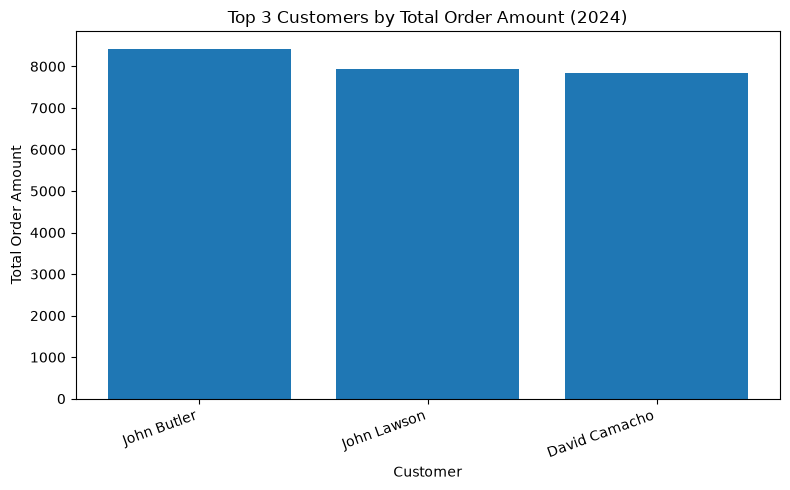

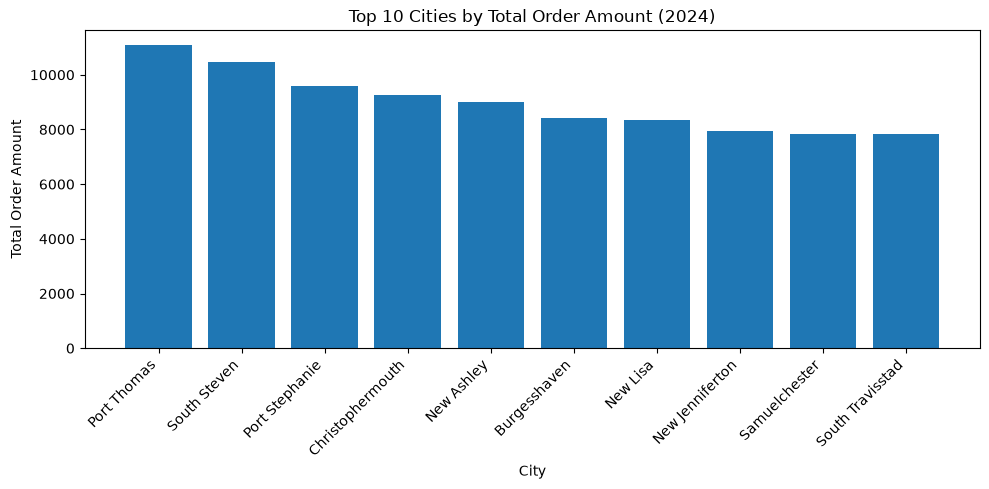

In [42]:
import matplotlib.pyplot as plt

top3_pd = top3_customers.toPandas()
city_top10_pd = city_totals.limit(10).toPandas()

plt.figure(figsize=(8, 5))
plt.bar(top3_pd['customer_name'], top3_pd['total_order_amount'])
plt.title('Top 3 Customers by Total Order Amount (2024)')
plt.xlabel('Customer')
plt.ylabel('Total Order Amount')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(city_top10_pd['customer_city'], city_top10_pd['city_total_order_amount'])
plt.title('Top 10 Cities by Total Order Amount (2024)')
plt.xlabel('City')
plt.ylabel('Total Order Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7. Output
a) Save final DataFrame from Task 5 as Parquet
b) Save top 3 customers from Task 6 as CSV

In [43]:
os.makedirs('outputs', exist_ok=True)

parquet_output_path = 'outputs/final_orders_with_customers.parquet'
top3_temp_dir = 'outputs/top3_customers_csv_temp'
top3_csv_final_path = 'outputs/top3_customers.csv'

final_df.write.mode('overwrite').parquet(parquet_output_path)

if os.path.exists(top3_temp_dir):
    shutil.rmtree(top3_temp_dir)
if os.path.exists(top3_csv_final_path):
    os.remove(top3_csv_final_path)

top3_customers.coalesce(1).write.mode('overwrite').option('header', True).csv(top3_temp_dir)
part_files = glob.glob(os.path.join(top3_temp_dir, 'part-*.csv'))
if part_files:
    shutil.copy(part_files[0], top3_csv_final_path)

print('Parquet saved to:', parquet_output_path)
print('Top 3 CSV saved to:', top3_csv_final_path)

Parquet saved to: outputs/final_orders_with_customers.parquet
Top 3 CSV saved to: outputs/top3_customers.csv


## 8. Reload from Parquet
Load DataFrame from the saved Parquet file and display content.

In [44]:
reloaded_df = spark.read.parquet('outputs/final_orders_with_customers.parquet')
reloaded_df.show(10, truncate=False)
print(f'reloaded_df_count: {reloaded_df.count()}')

+-----------+--------+----------+------------+----------+-----------+---------+----------------+-------------------+
|customer_id|order_id|order_date|order_amount|order_year|order_month|order_day|customer_name   |customer_city      |
+-----------+--------+----------+------------+----------+-----------+---------+----------------+-------------------+
|479        |1       |2024-06-10|450.13      |2024      |6          |10       |Erik Evans      |Johnstad           |
|110        |3       |2024-06-20|65.66       |2024      |6          |20       |Jonathan Bridges|New James          |
|487        |4       |2024-02-22|196.27      |2024      |2          |22       |Alyssa Schroeder|East Douglas       |
|466        |6       |2024-07-19|386.94      |2024      |7          |19       |Amy Middleton   |Port Sharifort     |
|323        |7       |2024-11-01|449.46      |2024      |11         |1        |Mary Bailey     |Stephensberg       |
|132        |8       |2024-06-09|472.4       |2024      |6      

In [45]:
spark.stop()